# **Problem Statement: Image Classification Using Convolutional Neural Networks (CNNs)**


The goal of this project is to design and implement a Convolutional Neural Network (CNN) for image classification using the CIFAR-10 dataset. The project involves training a CNN to classify images into 10 distinct categories, applying data augmentation techniques to enhance model performance, and visualizing feature maps from the convolutional layers to understand feature extraction.

**Objectives:**
1. **Train a CNN Model**  
   - Build a CNN architecture and train it on the CIFAR-10 dataset.  
   - Optimize the network to achieve high accuracy on the test set.  

2. **Enhance Model Performance**  
   - Implement data augmentation techniques (e.g., rotation, flipping, cropping) to increase the diversity of the training data and improve the model's robustness.

3. **Visualize Feature Maps**  
   - Extract and visualize feature maps from the convolutional layers to analyze how the model learns and processes image features.

4. **Experiment with Architectures**  
   - Compare the performance of different CNN architectures (e.g., LeNet, AlexNet, or custom designs) to identify the most effective model for this task.

 **Deliverables:**
1. **Training Results:**  
   - Detailed training logs, including accuracy and loss curves for both training and validation datasets.  

2. **Test Performance:**  
   - Final evaluation of the model on the CIFAR-10 test set with performance metrics such as accuracy, precision, recall, and F1-score.  

3. **Feature Map Visualizations:**  
   - Visual representations of feature maps from the convolutional layers to demonstrate feature extraction at different stages of the model.

4. **Comparative Analysis:**  
   - Performance comparison between various CNN architectures tested during the project, along with observations and insights.

**Learning Outcomes:**
- Gain a deeper understanding of image classification tasks and the role of CNNs in processing image data.
- Develop skills in feature extraction and analysis using convolutional layers.
- Learn to apply data augmentation to improve model performance and generalization.
- Build proficiency in evaluating and comparing different CNN architectures.

# *Importing Packages and Dataset*

In [ ]:
# import packages
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


In [ ]:
# import CIFAR-10 dataset
(train_images, train_labels), (val_images, val_labels) = tf.keras.datasets.cifar10.load_data()
(train_images.shape, train_labels.shape), (val_images.shape, val_labels.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

In [ ]:
# Split train data into train and test data
train_images, test_images, train_labels, test_labels = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)
train_images.shape,train_labels.shape,  test_images.shape, test_labels.shape


((45000, 32, 32, 3), (45000, 1), (5000, 32, 32, 3), (5000, 1))

array([[[ 96, 110, 131],
        [115, 120, 141],
        [114, 118, 146],
        ...,
        [ 73,  98, 125],
        [ 68,  94, 120],
        [ 63,  89, 116]],

       [[107, 120, 142],
        [118, 125, 145],
        [118, 124, 151],
        ...,
        [ 75, 100, 127],
        [ 70,  96, 123],
        [ 66,  91, 118]],

       [[113, 125, 147],
        [118, 125, 145],
        [119, 128, 154],
        ...,
        [ 73,  99, 126],
        [ 70,  96, 123],
        [ 66,  92, 119]],

       ...,

       [[ 36,  60,  51],
        [ 35,  62,  53],
        [ 39,  69,  58],
        ...,
        [ 45,  78,  64],
        [ 41,  73,  60],
        [ 40,  69,  57]],

       [[ 35,  61,  53],
        [ 37,  65,  56],
        [ 39,  70,  60],
        ...,
        [ 44,  77,  65],
        [ 43,  75,  63],
        [ 44,  72,  62]],

       [[ 32,  59,  50],
        [ 36,  66,  56],
        [ 36,  68,  57],
        ...,
        [ 35,  70,  58],
        [ 35,  68,  57],
        [ 36,  66,  56]]], dtype=uint8)
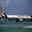

In [ ]:
train_images[569]

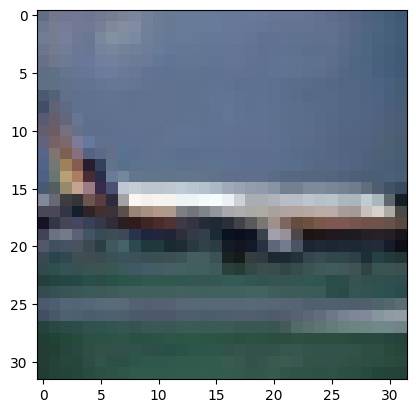

In [ ]:
plt.imshow(train_images[569])

In [ ]:
print(train_labels[569][0])

0


In [ ]:
# Class Names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# **Becoming One With the Data**

Run the below cell to become familiar with the dataset

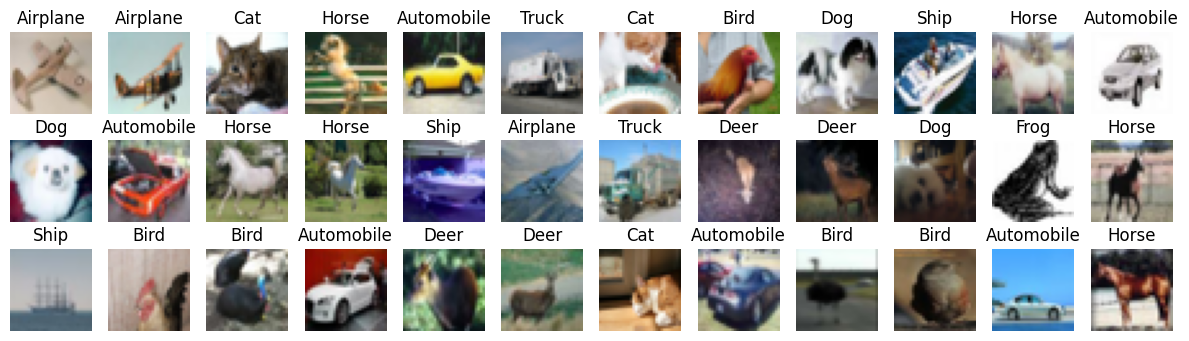

In [ ]:
fig, ax = plt.subplots(nrows =3, ncols=12, figsize=(15,4))  #(width, Height)
for i in range(0,3):
  for j in range(0,12):
    index = random.randint(0, len(train_images))
    ax[i,j].imshow(train_images[index])
    ax[i,j].set_title(f"{class_names[train_labels[index][0]]}")
    ax[i,j].axis(False)

# **Data Preprocessing**

In [ ]:
# Create ImageDataGenerator Training Instance for Original dataset
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator Validation Instance
val_datagen = ImageDataGenerator(rescale=1/255.0)

# Create ImageDataGenerator Testing Instance
test_datagen = ImageDataGenerator(rescale=1/255.0)


In [ ]:
# Load Training data
train_data = train_datagen.flow(train_images, train_labels, batch_size=32, shuffle=True)

# Load Validation data
val_data = val_datagen.flow(val_images, val_labels, batch_size=32)

# Load Testing data
test_data = test_datagen.flow(test_images, test_labels, batch_size=32, shuffle=False)


In [ ]:
len(train_data), len(val_data), # len(test_data)

(1407, 313)

In [ ]:
# Check a batch
images, lables = next(train_data)
print(f"Batch Shape: {images.shape, lables.shape}")

Batch Shape: ((32, 32, 32, 3), (32, 1))


**Train data augmentation**

In [ ]:
# Create ImageDataGenerator Training instance with data Augmentation
train_datagen_augmented = ImageDataGenerator(rescale = 1/255.0,
                                             zoom_range = 0.2,
                                             shear_range = 0.2,
                                             rotation_range = 0.2,
                                             width_shift_range = 0.2,
                                             height_shift_range = 0.2,
                                             horizontal_flip = True)

In [ ]:
# Load the Training Data And Augment it
print("Augmented Training Data")
train_data_augmented = train_datagen_augmented.flow(train_images,
                                                    train_labels,
                                                    batch_size = 32,
                                                    shuffle= True)

Augmented Training Data


**Functions to preprocess custom images and predict class and plot image**

In [ ]:
# Load and Preprocess image
def load_and_prep_image(filename, img_shape=32):
  """
  Takes image, convert it into tensor, reshapes it to [img_shape, img_shape],
  and rescale it to get all the values in between 0 and 1
  """
  # Read the image file
  img = tf.io.read_file(filename)
  # Convert image into tensor
  img = tf.image.decode_image(img)
  # Resize the image
  img = tf.image.resize(img, size=[img_shape, img_shape])
  # Rescale image
  img = img/255.0
  # change dimensions to (batch_size, img_height, img_width, Color_channels)
  img = tf.expand_dims(img, axis=0)

  return img

In [ ]:
# Predict and Display
def predict_and_plot(model, filename, class_names = class_names):
  """
  Takes the the image file, predict its label using model and Plot the image with predicted label
  """

  # preprocess image
  image = load_and_prep_image(filename)
  # predict class
  pred = model.predict(image)

  if len(pred[0]) > 1:
    # for multiclass classification
    pred_label = class_names[tf.argmax(pred[0])]
  else:
    # assign actual class label for binary classification
    pred_label = class_names[int(tf.round(pred[0]))]

  # plot the image with predicted class
  img = mpimg.imread(filename)
  plt.imshow(img)
  plt.title(f"Prediction: {pred_label}")
  plt.axis(False)

**Function to plot Confusion Matrix**:

In [ ]:
# fubction to plot confusion matrix
def plot_confusion_matrix(conf_matrix, class_labels = class_names):
  # Visualize Confusion Matrix through Seaborn
  # Initialize an annotation matrix
  annot = np.empty_like(conf_matrix, dtype='object')

  # Populate the annotation matrix with counts and row-wise percentages
  for i in range(conf_matrix.shape[0]):
    row_sum = conf_matrix[i].sum()  # Total instances for true class i
    for j in range(conf_matrix.shape[1]):
        count = conf_matrix[i, j]
        percentage = (count / row_sum) * 100  # Row-wise percentage
        annot[i, j] = f'{count}\n{percentage:.2f}%'

  # Plot heatmap
  fig, ax = plt.subplots(figsize=(9, 9))
  sns.heatmap(conf_matrix, annot=annot, fmt='', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels,
            square=True, linewidths=0.5, annot_kws={"size": 8})

  # Set axis labels and title
  ax.set_title("Confusion Matrix", fontsize=18)
  ax.set_xlabel("Predicted label", fontsize=10)
  ax.set_ylabel("True label", fontsize=10)

  # Fix tick alignment
  ax.set_xticklabels(class_labels, ha="right", fontsize=12)  # Rotate for readability
  ax.set_yticklabels(class_labels, fontsize=12)

  plt.tight_layout()
  plt.show()


# **Final Successful Experiment with VGG16**

In [ ]:
model_vgg16_2 = tf.keras.models.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # tf.keras.layers.Dropout(0.4),

    # Block 4
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # tf.keras.layers.Dropout(0.2),

    # Block 5
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    # tf.keras.layers.Dropout(0.2),

    # Fully Connected Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4096, activation='relu'),
    # tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(4096, activation='relu'),
    # tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Metrics
Metrics = [
    'accuracy'
]

# Compile the model
model_vgg16_2.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=Metrics
)

# Model summary
model_vgg16_2.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 4, 4, 512)           │       1,180,1

 Total params: 33,655,114 (128.38 MB)

 Trainable params: 33,646,666 (128.35 MB)

 Non-trainable params: 8,448 (33.00 KB)

In [ ]:
history_11 = model_vgg16_2.fit(train_data_augmented, epochs=100, validation_data=val_data)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 123s 70ms/step - accuracy: 0.2557 - loss: 2.1428 - val_accuracy: 0.3399 - val_loss: 1.8628
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.4177 - loss: 1.5619 - val_accuracy: 0.2313 - val_loss: 4.0624
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.5413 - loss: 1.2966 - val_accuracy: 0.6273 - val_loss: 1.0637
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.6341 - loss: 1.0662 - val_accuracy: 0.5991 - val_loss: 1.1870
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6810 - loss: 0.9426 - val_accuracy: 0.6634 - val_loss: 1.0754
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.7221 - loss: 0.8365 - val_accuracy: 0.6852 - val_loss: 0.9675
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.7487 - loss: 0.7636 - val_accuracy: 0.7622 - val_loss: 0.7236
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.7713 - lo

<Axes: title={'center': 'Accuracy/Loss Curves - VGG16 - Model 2'}, xlabel='Epochs', ylabel='Accuracy/Loss'>

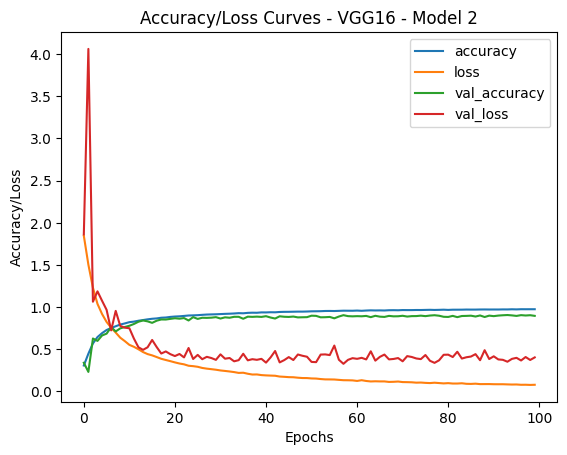

In [ ]:
pd.DataFrame(history_11.history).plot(title='Accuracy/Loss Curves - VGG16 - Model 2', xlabel='Epochs', ylabel='Accuracy/Loss')

In [ ]:
loss, accuracy = model_vgg16_2.evaluate(test_data)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

 15/157 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9250 - loss: 0.3110

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9048 - loss: 0.3561
Test Loss: 0.3748532831668854
Test Accuracy: 0.9014000296592712


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# make predictions
predictions = model_vgg16_2.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = test_labels
conf_matrix = confusion_matrix(true_labels, predicted_labels)
conf_matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


array([[437,   5,   1,   4,   0,   0,   2,   1,   5,  21],
       [  0, 462,   0,   0,   0,   0,   1,   1,   4,  19],
       [ 16,   0, 453,  14,   6,   3,  24,   8,   2,   1],
       [  5,   2,  15, 395,  11,  56,  28,   4,   5,   2],
       [  2,   0,   6,   9, 431,  10,  15,  10,   1,   2],
       [  3,   3,  13,  29,  11, 423,  13,   6,   1,   2],
       [  1,   2,   6,   2,   2,   1, 469,   0,   2,   0],
       [  1,   2,   7,   4,   6,  11,   2, 471,   2,   3],
       [ 11,   1,   3,   0,   0,   0,   0,   0, 478,  10],
       [  2,   4,   1,   0,   0,   1,   0,   0,   4, 488]])

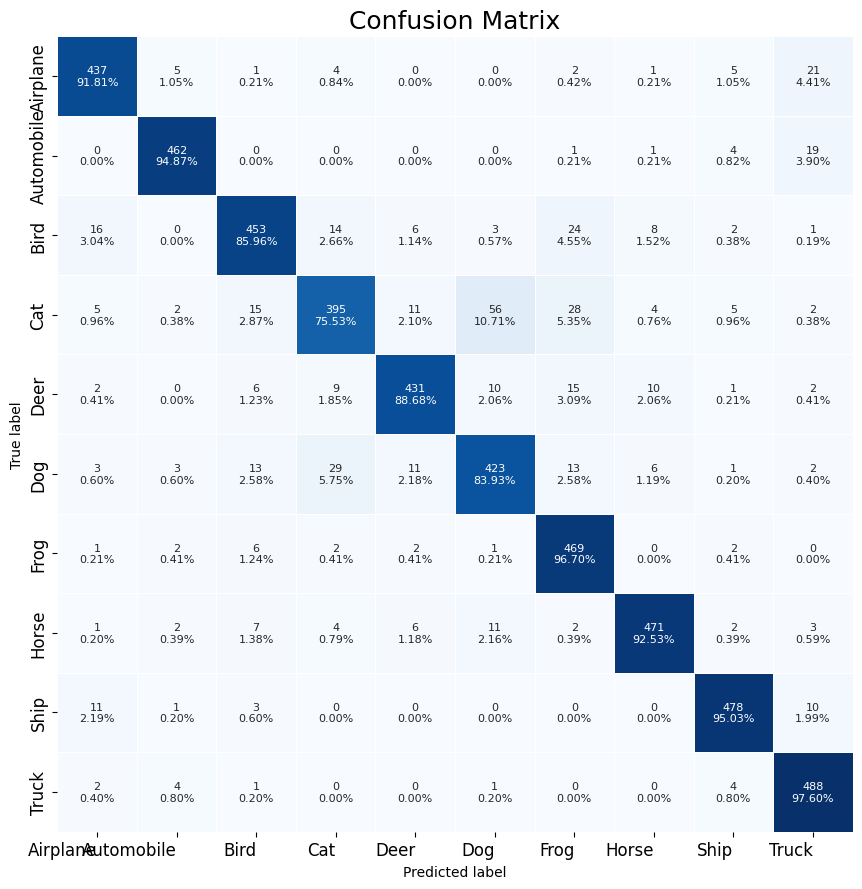

In [ ]:
plot_confusion_matrix(conf_matrix)

**Making Predictions on Custom Data**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


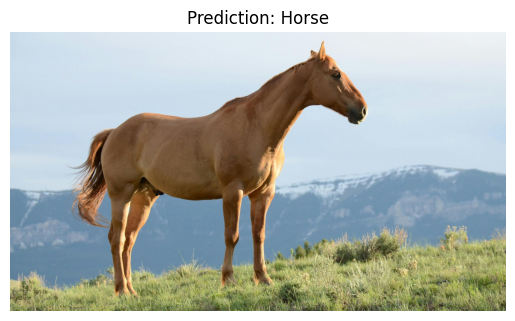

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/horse.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


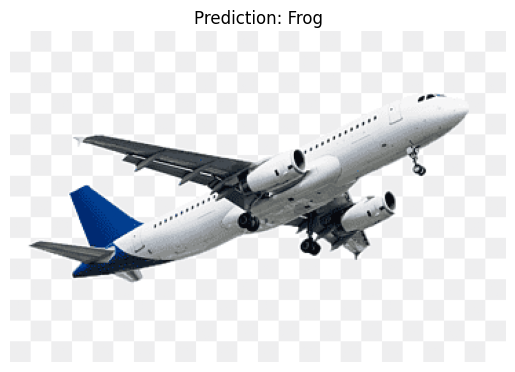

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Airplane.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


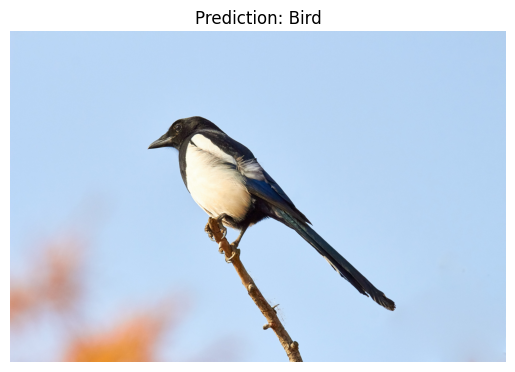

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Bird.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


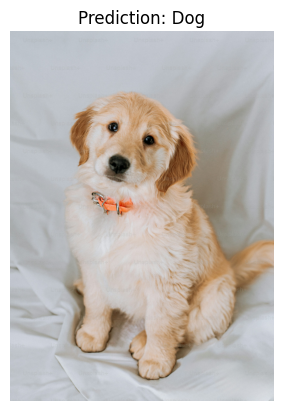

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Dog.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


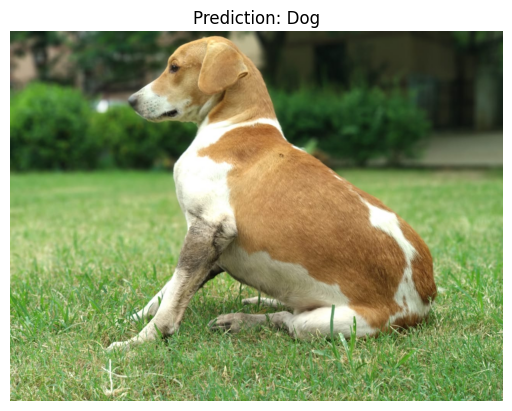

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Dogg.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


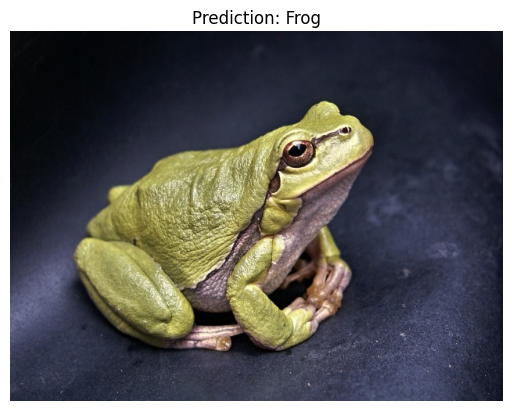

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Frog.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


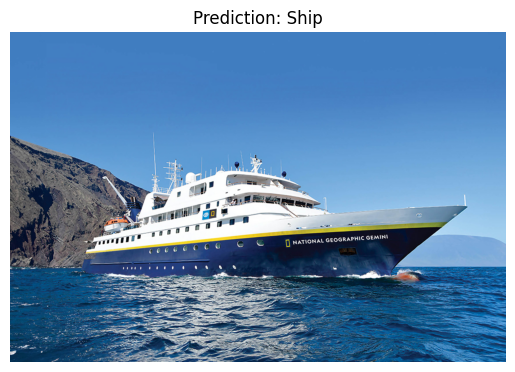

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Ship.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


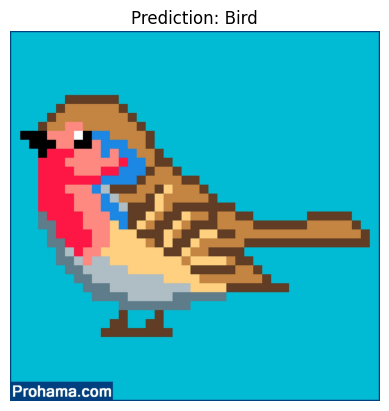

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/bird.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


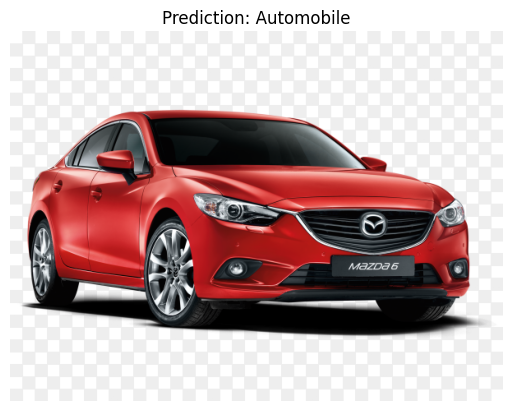

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/car.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


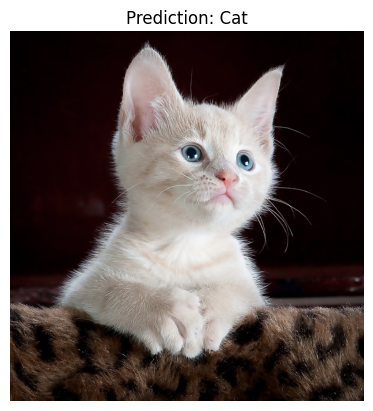

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/cat.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


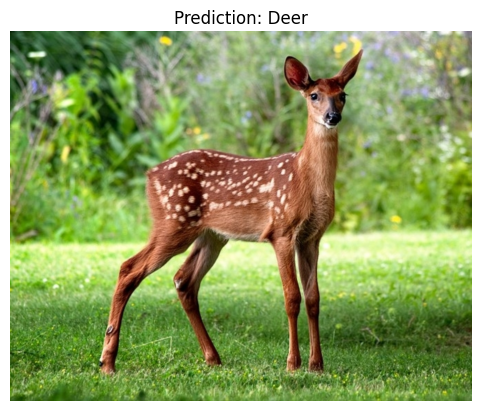

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/deer.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


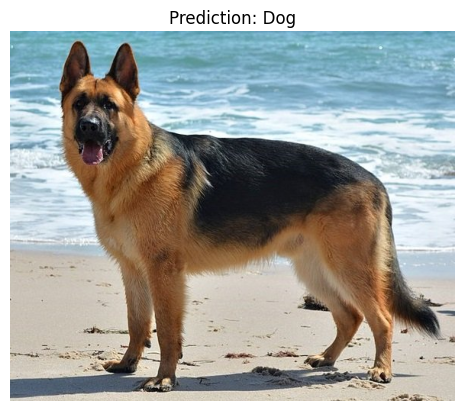

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/dog.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


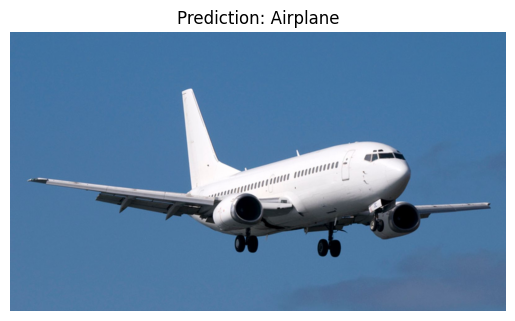

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/Plane.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


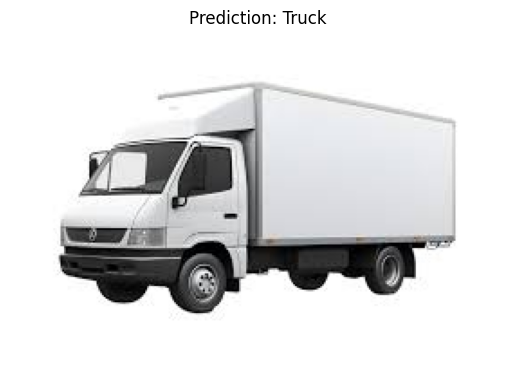

In [ ]:
predict_and_plot(model_vgg16_2, '/content/sample_data/truck.jpg')

**VGG16 successfully classified the images and assigned them correct labels**

# **Export the Model**

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("model_vgg16", exist_ok=True)

# Now save the model
model_vgg16_2.save("model_vgg16/cifar10_model.keras")


In [ ]:
from google.colab import files

# For .keras or .h5 files
files.download("model_vgg16/cifar10_model.keras")




In [ ]:
import shutil

# Zip the folder
shutil.make_archive("Cifar-10/model_vgg16_zip", 'zip', "model_vgg16")


In [ ]:
# For zipped folders (SavedModel)
files.download("/content/Cifar-10/model_vgg16_zip.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Load trained Model and Make Predictions**

In [ ]:
import zipfile
import os
from tensorflow.keras.models import load_model

In [ ]:
from tensorflow.keras.models import load_model

# Set the correct model file path
model_path = os.path.join('/content/model_vgg16', 'cifar10_model.keras')  # Update with the correct filename

# Verify if the file exists
if os.path.isfile(model_path):
    print(f"Model file found: {model_path}")
else:
    raise FileNotFoundError("Model file not found. Please check the filename and path.")

# Load the model
model_vgg16 = load_model(model_path)
print("Model loaded successfully!")


Model file found: /content/model_vgg16/cifar10_model.keras
Model loaded successfully!


**Function to print outputs in Grid**

In [ ]:
import os
# Main function to predict and display multiple images
def plot_custome_data_outputs(model, images_path, img_shape=32, class_names=class_names, save_path="output_grid.png"):

    # Supported image file extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')

    # Collect all valid image file paths
    image_paths = [os.path.join(images_path, f)
                   for f in os.listdir(images_path)
                   if f.lower().endswith(valid_extensions)]

    if not image_paths:
        print("No valid image files found in the directory.")
        return

    # Set up the subplot grid (6 rows, 2 columns)
    num_images = min(len(image_paths), 12)  # Limit to 12 images
    fig, axes = plt.subplots(6, 2, figsize=(8, 18))  # Reduced figure size
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    # Process each image and display predictions
    for i, img_path in enumerate(image_paths[:num_images]):
        # Load and preprocess the image
        image = load_and_prep_image(img_path, img_shape=img_shape)
        prediction = model.predict(image, verbose=0)

        # Determine the predicted class label
        if len(prediction[0]) > 1:  # Multiclass classification
            pred_label = class_names[tf.argmax(prediction[0])]
        else:  # Binary classification
            pred_label = class_names[int(tf.round(prediction[0]))]

        # Display the image with prediction
        img = plt.imread(img_path)  # Load image for display
        axes[i].imshow(img)
        axes[i].set_title(f"Prediction: {pred_label}", fontsize=10)
        axes[i].axis("off")

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    # Save the figure to the specified path
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Grid of predictions saved at: {save_path}")

    plt.show()


Grid of predictions saved at: output_grid.png


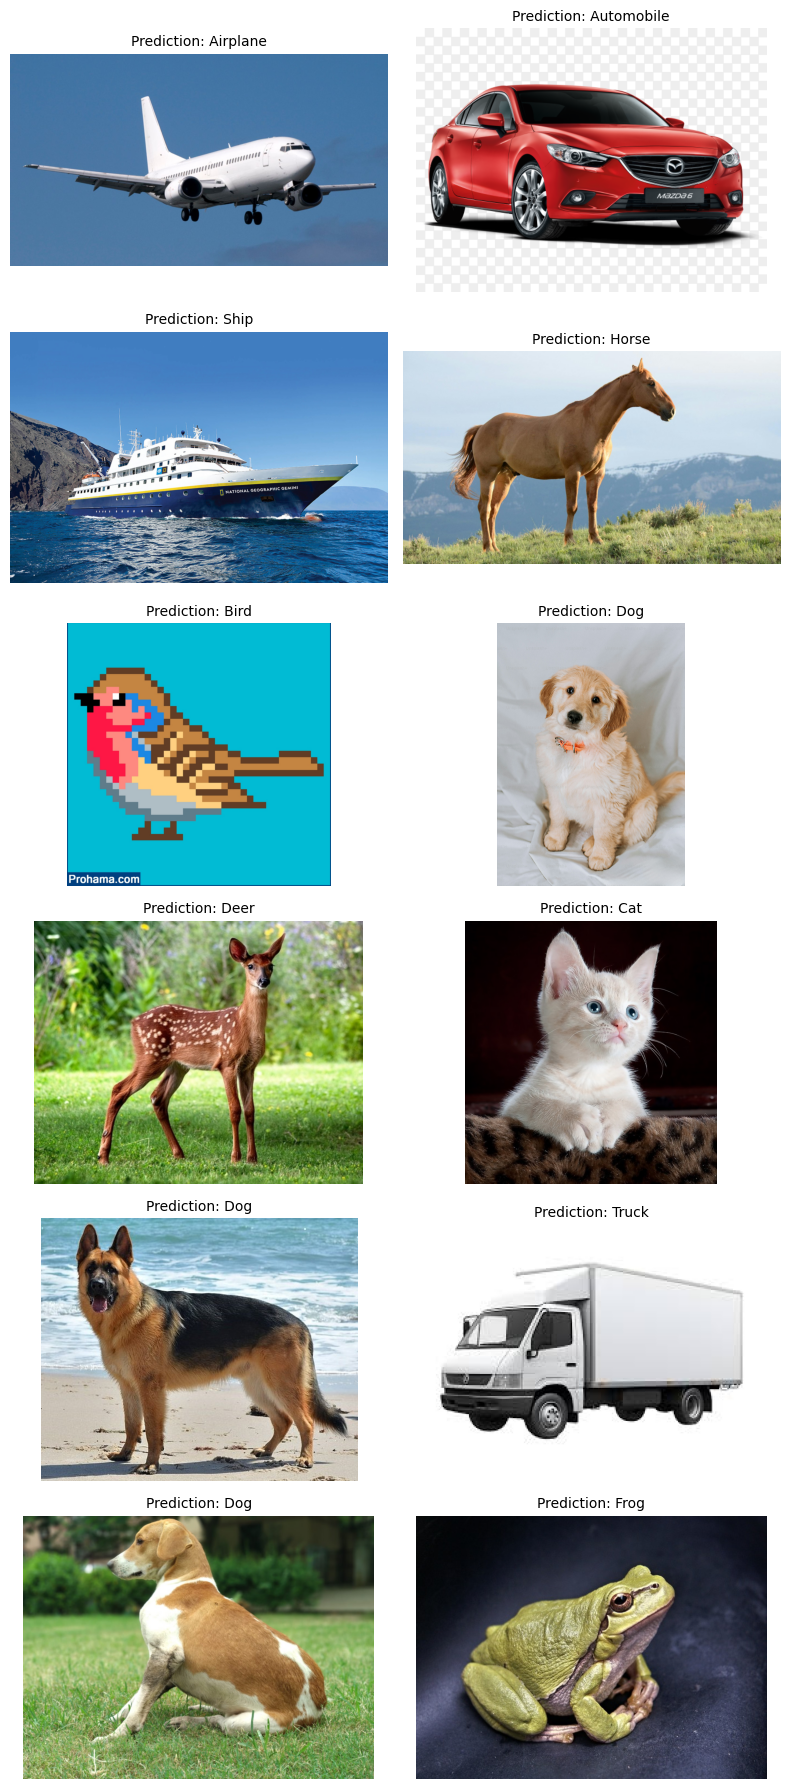

In [ ]:
plot_custome_data_outputs(model_vgg16,'/content/sample_data')

In [ ]:
# predict_and_plot(model_vgg16, '/content/sample_data/horse.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/Airplane.png')
# predict_and_plot(model_vgg16, '/content/sample_data/Bird.jpeg')
# predict_and_plot(model_vgg16, '/content/sample_data/Dog.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/Dogg.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/Frog.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/Ship.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/bird.jpg')
# predict_and_plot(model_vgg16, '/content/sample_data/car.png')
# predict_and_plot(model_vgg16, '/content/sample_data/cat.jpeg')
# predict_and_plot(model_vgg16, '/content/sample_data/deer.jpeg')
# predict_and_plot(model_vgg16, '/content/sample_data/dog.jpeg')
# predict_and_plot(model_vgg16, '/content/sample_data/plane.png')
# predict_and_plot(model_vgg16, '/content/sample_data/truck.jpg')
